## Qeq 预测电荷 vs 真实电荷（NaCl）

用 fit-4hdnnp-NaCl 训练好的模型，在验证集上比较 **Qeq 算出的 q_eq** 与 **extxyz 中的参考电荷 charge**，并画图。

In [1]:
import os, sys
from pathlib import Path

import numpy as np
import torch

# 本 notebook 在 fit-4hdnnp-NaCl 下，CACE-SOG-Qeq 为上一级
cwd = Path(os.getcwd()).resolve()
if cwd.name == "fit-4hdnnp-NaCl-initial":
    ROOT_DIR = cwd.parent
    DATA_DIR = cwd
else:
    ROOT_DIR = cwd
    DATA_DIR = cwd / "fit-4hdnnp-NaCl-initial"
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

import cace
from cace.data.extxyz_charge import get_dataset_from_extxyz_with_charge
from cace.tools import torch_geometric

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("ROOT_DIR:", ROOT_DIR)
print("DATA_DIR:", DATA_DIR)
print("device:", device)

ROOT_DIR: /work/home/acrb3qk4vo/SOG-Qeq/SOG-Net/CACE-SOG-Qeq
DATA_DIR: /work/home/acrb3qk4vo/SOG-Qeq/SOG-Net/CACE-SOG-Qeq/fit-4hdnnp-NaCl-initial
device: cpu


In [2]:
from cace.tools.scatter import scatter_sum
from cace.representations import Cace
from cace.modules import PolynomialCutoff, BesselRBF
from cace.models.atomistic import NeuralNetworkPotential

# 如果你加载的是“整模型 .pth”，需要先在当前环境定义训练脚本里用到的自定义模块类名。
class SystemChargeFromAtomicCharges(torch.nn.Module):
    def __init__(self, charges_key: str = "charge", output_key: str = "system_charge"):
        super().__init__()
        self.charges_key = charges_key
        self.output_key = output_key
        self.model_outputs = [output_key]

    def forward(self, data: dict, **kwargs):
        if self.charges_key not in data or data[self.charges_key] is None:
            num_graphs = 1 if data.get("batch", None) is None else int(data["batch"].max().item()) + 1
            data[self.output_key] = torch.zeros(
                (num_graphs,), device=data["positions"].device, dtype=data["positions"].dtype
            )
            return data
        q = data[self.charges_key]
        if q.dim() > 1:
            q = q.view(-1)
        system_q = q.sum().view(1) if data.get("batch", None) is None else scatter_sum(q, data["batch"], dim=0)
        data[self.output_key] = system_q
        return data


def build_model(device: torch.device) -> NeuralNetworkPotential:
    cutoff = 5.29
    Fourier_node = 18

    radial_basis = BesselRBF(cutoff=cutoff, n_rbf=6, trainable=True)
    cutoff_fn = PolynomialCutoff(cutoff=cutoff)

    rep = Cace(
        zs=[11, 17],
        n_atom_basis=2,
        embed_receiver_nodes=True,
        cutoff=cutoff,
        cutoff_fn=cutoff_fn,
        radial_basis=radial_basis,
        n_radial_basis=8,
        max_l=3,
        max_nu=3,
        num_message_passing=0,
        type_message_passing=["Bchi"],
        args_message_passing={"Bchi": {"shared_channels": False, "shared_l": False}},
        device=device,
        timeit=False,
        forward_features=["atomic_numbers"],
    ).to(device)

    sr_energy = cace.modules.atomwise.Atomwise(
        n_layers=3,
        output_key="SR_energy",
        n_hidden=[32, 16],
        use_batchnorm=False,
        add_linear_nn=True,
    )

    chi = cace.modules.Atomwise(
        n_layers=3,
        n_hidden=[24, 12],
        n_out=1,
        per_atom_output_key="chi",
        output_key="tot_chi",
        residual=False,
        add_linear_nn=True,
        post_process=torch.square,
        bias=False,
    )

    system_charge_from_q = SystemChargeFromAtomicCharges(charges_key="charge", output_key="system_charge")

    charge_eq = cace.modules.ChargeEq(
        dl=1.5,
        sigma=1.0,
        elements=[11, 17],
        feature_key="chi",
        output_key="q_eq",
        ewald_key="SOG_potential",
        system_charge=None,
        remove_self_interaction=True,
        aggregation_mode="sum",
        use_sog_kernel=True,
        sog_num_components=Fourier_node,
    )

    e_add = cace.modules.FeatureAdd(
        feature_keys=["SR_energy", "SOG_potential"],
        output_key="CACE_energy",
    )

    # 这里做“电荷对比”不需要 Forces，避免 autograd 依赖
    model = NeuralNetworkPotential(
        input_modules=None,
        representation=rep,
        output_modules=[sr_energy, chi, system_charge_from_q, charge_eq, e_add],
    ).to(device)

    return model


# 加载模型：如果是 checkpoint.pt（dict），需要 build_model + load_state_dict
model_path = DATA_DIR / "loss_data" / "N_18_BSA_min_rmse_e20260312_154625_model.pth"
# if not model_path.exists():
#     model_path = DATA_DIR / "best_model.pth"
# assert model_path.exists(), f"No model found under {DATA_DIR / 'loss_data'}"

obj = torch.load(str(model_path), map_location=device, weights_only=False)

# 统一使用本 notebook 中的 build_model 构建“无 Forces”的推理模型，
# 然后只加载 state_dict，避免 Forces 在 torch.no_grad() 下调用 autograd.grad。
model = build_model(device)
if isinstance(obj, dict) and "model_state_dict" in obj:
    state_dict = obj["model_state_dict"]
    print("Loaded checkpoint dict (model_state_dict).")
else:
    state_dict = obj.state_dict()
    print("Loaded full model object; using its state_dict.")

missing, unexpected = model.load_state_dict(state_dict, strict=False)
print("missing keys:", len(missing), "unexpected keys:", len(unexpected))

model.to(device)
model.eval()

Loaded full model object; using its state_dict.
missing keys: 0 unexpected keys: 12


NeuralNetworkPotential(
  (postprocessors): ModuleList()
  (representation): Cace(
    (node_onehot): NodeEncoder(num_classes=2)
    (node_embedding_sender): NodeEmbedding(num_classes=2, embedding_dim=2)
    (node_embedding_receiver): NodeEmbedding(num_classes=2, embedding_dim=2)
    (edge_coding): EdgeEncoder(directed=True)
    (radial_basis): BesselRBF(cutoff=5.289999961853027, n_rbf=6, trainable=True)
    (cutoff_fn): PolynomialCutoff(p=6.0, cutoff=5.289999961853027)
    (angular_basis): AngularComponent(l_max=3)
    (radial_transform): SharedRadialLinearTransform(
      (weights): ParameterList(
          (0): Parameter containing: [torch.float32 of size 6x8x4]
          (1): Parameter containing: [torch.float32 of size 6x8x4]
          (2): Parameter containing: [torch.float32 of size 6x8x4]
          (3): Parameter containing: [torch.float32 of size 6x8x4]
      )
    )
    (symmetrizer): Symmetrizer()
    (message_passing_list): ModuleList()
  )
  (input_modules): ModuleList(
  

In [3]:
# 加载与训练时相同的数据划分（带参考电荷）
cutoff = 5.29
collection = get_dataset_from_extxyz_with_charge(
    train_path=str(DATA_DIR / "NaCl.xyz"),
    cutoff=cutoff,
    valid_fraction=0.1,
    seed=1,
    atomic_energies={11: -4417.07609365649, 17: -12516.880649933015},
)
valid_dataset = collection.valid
valid_loader = torch_geometric.DataLoader(
    valid_dataset,
    batch_size=10,
    shuffle=False,
    drop_last=False,
)
print("valid samples:", len(valid_dataset))

valid samples: 500


In [5]:
# 跑验证集，收集 q_eq（预测）与 charge（参考）
# 注意：PyG 的 batch["batch"] 在每个 mini-batch 内从 0 重新编号，不能跨 mini-batch 直接 concat 当全局结构 id。
# 因此这里直接在每个 mini-batch 内按结构求和，得到每结构 Q_tot_ref / Q_tot_pred。
q_pred_list, q_ref_list, z_list = [], [], []
chi_list, J_i_list = [], []
Q_tot_pred_list, Q_tot_ref_list = [], []

J_elem = None

# 本 notebook 里的 model 不包含 Forces，因此可安全使用 no_grad
# with torch.no_grad():
for batch in valid_loader:
    batch = batch.to(device)
    out = model(batch.to_dict())  # NeuralNetworkPotential.forward 期望 dict

    q_eq = out["q_eq"].detach().view(-1)
    chi = out["chi"].detach().view(-1)

    # J 输出来自 ChargeEq（我已在代码中加入 data['J_elem']/data['J_i']）
    if J_elem is None and ("J_elem" in out) and (out["J_elem"] is not None):
        J_elem = out["J_elem"].detach().view(-1).cpu().numpy()
    J_i = out.get("J_i", None)
    if J_i is not None:
        J_i = J_i.detach().view(-1)

    q_ref_t = batch["charge"].view(-1)
    b = batch["batch"]

    q_pred_list.append(q_eq.cpu().numpy())
    q_ref_list.append(q_ref_t.cpu().numpy())
    z_list.append(batch["atomic_numbers"].cpu().numpy())
    chi_list.append(chi.cpu().numpy())
    if J_i is not None:
        J_i_list.append(J_i.cpu().numpy())

    Q_tot_pred_list.append(scatter_sum(q_eq, b, dim=0).cpu().numpy())
    Q_tot_ref_list.append(scatter_sum(q_ref_t, b, dim=0).cpu().numpy())

q_pred = np.concatenate([x.reshape(-1) for x in q_pred_list])
q_ref = np.concatenate([x.reshape(-1) for x in q_ref_list])
z_all = np.concatenate([x.reshape(-1) for x in z_list])
chi_all = np.concatenate([x.reshape(-1) for x in chi_list])
J_i_all = np.concatenate([x.reshape(-1) for x in J_i_list]) if len(J_i_list) else None

Q_tot_pred = np.concatenate([x.reshape(-1) for x in Q_tot_pred_list])
Q_tot_ref  = np.concatenate([x.reshape(-1) for x in Q_tot_ref_list])

print("Total atoms:", len(q_pred))
print("q_pred: min={:.4f}, max={:.4f}".format(q_pred.min(), q_pred.max()))
print("q_ref:  min={:.4f}, max={:.4f}".format(q_ref.min(), q_ref.max()))
print("chi:    min={:.4f}, max={:.4f}".format(chi_all.min(), chi_all.max()))
print("Total structures (valid):", len(Q_tot_ref))

print("J_elem (per element in ChargeEq.elements order):", J_elem)
if J_i_all is not None:
    print("J_i: min={:.4f}, max={:.4f}".format(J_i_all.min(), J_i_all.max()))

Total atoms: 8265
q_pred: min=0.2385, max=0.8769
q_ref:  min=-0.4934, max=0.7379
chi:    min=-0.0027, max=0.0188
Total structures (valid): 500
J_elem (per element in ChargeEq.elements order): [1.43354035e-11 1.22493066e-11]
J_i: min=0.0000, max=0.0000


In [4]:
print("q_pred: min/max =", q_pred.min(), q_pred.max())
mask_na = z_all == 11
mask_cl = z_all == 17
print("q_pred(Na) min/max:", q_pred[mask_na].min(), q_pred[mask_na].max())
print("q_pred(Cl) min/max:", q_pred[mask_cl].min(), q_pred[mask_cl].max())



NameError: name 'q_pred' is not defined

In [11]:
print("q_ref: min/max =", q_ref.min(),q_ref.max())
mask_na = z_all == 11
mask_cl = z_all == 17
print("q_ref(Na) min/max:", q_ref[mask_na].min(), q_ref[mask_na].max())
print("q_ref(Cl) min/max:", q_ref[mask_cl].min(), q_ref[mask_cl].max())

q_ref: min/max = -0.4934162 0.7378678
q_ref(Na) min/max: 0.32380393 0.7378678
q_ref(Cl) min/max: -0.4934162 -0.24805751


In [5]:
# 误差统计（说明：训练只用了 energy+force loss，未对 charge 监督，故 q_eq 与参考电荷 MAE 可能较大）
err = q_pred - q_ref
mae = np.abs(err).mean()
rmse = np.sqrt((err**2).mean())
print("MAE  (|q_pred - q_ref|): {:.6f}".format(mae))
print("RMSE: {:.6f}".format(rmse))

mask_na = z_all == 11
mask_cl = z_all == 17
if mask_na.any():
    print("Na MAE:  {:.6f}".format(np.abs(q_pred[mask_na] - q_ref[mask_na]).mean()))
if mask_cl.any():
    print("Cl MAE:  {:.6f}".format(np.abs(q_pred[mask_cl] - q_ref[mask_cl]).mean()))


# 每结构总电荷：Q_tot 由 system_charge_from_q 从参考 charge 得到，故 sum(q_pred) 应等于 sum(q_ref)
# 这里直接使用上一格已经按结构聚合好的 Q_tot_ref / Q_tot_pred
if "Q_tot_ref" not in globals() or "Q_tot_pred" not in globals():
    raise NameError("Q_tot_ref/Q_tot_pred 未定义：请先运行上一格『跑验证集，收集 q_eq/charge』")

print("\n--- 每结构总电荷 Q_tot（参考应为 +1，本数据集为 +1）---")
print("Q_tot_ref   mean={:.6f}, std={:.6f}".format(Q_tot_ref.mean(), Q_tot_ref.std()))
print("Q_tot_pred  (raw, ChargeEq 内部缩放后) mean={:.6f}, std={:.6f}".format(Q_tot_pred.mean(), Q_tot_pred.std()))

# ChargeEq 内部对电荷做了 normalization_factor 缩放，
# 约束的是 sum( q_tilde_i ) = normalization_factor * Q_tot_ref。
# 为了直接和物理总电荷 Q_tot_ref=1 对比，需要把 Q_tot_pred 除回去。
from cace.modules import ChargeEq
charge_eq_modules = [m for m in model.output_modules if isinstance(m, ChargeEq)]
if len(charge_eq_modules) > 0:
    norm_factor = float(charge_eq_modules[0].normalization_factor)
    Q_tot_pred_rescaled = Q_tot_pred * norm_factor
    print("normalization_factor (ChargeEq): {:.6f}".format(norm_factor))
    print("Q_tot_pred  (rescaled to physical units) mean={:.6f}, std={:.6f}".format(Q_tot_pred_rescaled.mean(), Q_tot_pred_rescaled.std()))
    print("|Q_tot_pred_rescaled - Q_tot_ref| 每结构 MAE: {:.6f}".format(np.abs(Q_tot_pred_rescaled - Q_tot_ref).mean()))
else:
    print("[Warning] model 中未找到 ChargeEq 模块，无法做 Q_tot 反归一化。")

# print("|Q_tot_pred - Q_tot_ref| (raw, 未反归一化) 每结构 MAE: {:.6f}".format(np.abs(Q_tot_pred - Q_tot_ref).mean()))

MAE  (|q_pred - q_ref|): 0.530548
RMSE: 0.686756
Na MAE:  0.120271
Cl MAE:  0.968005

--- 每结构总电荷 Q_tot（参考应为 +1，本数据集为 +1）---
Q_tot_ref   mean=1.000000, std=0.000000
Q_tot_pred  (raw, ChargeEq 内部缩放后) mean=9.489330, std=0.000002
normalization_factor (ChargeEq): 0.105382
Q_tot_pred  (rescaled to physical units) mean=1.000000, std=0.000000
|Q_tot_pred_rescaled - Q_tot_ref| 每结构 MAE: 0.000000


In [ ]:
from cace.tools import Metrics
collection_f = get_dataset_from_extxyz_with_charge(
    train_path=str(DATA_DIR / "NaCl.xyz"),
    cutoff=cutoff,
    valid_fraction=0.1,
    seed=1,
    atomic_energies={11: -4417.07609365649, 17: -12516.880649933015},
)
train_dataset_f = collection_f.train
valid_dataset_f = collection_f.valid

train_loader_metrics = torch_geometric.DataLoader(
    train_dataset_f,
    batch_size=5,
    shuffle=True,
    drop_last=True,
)
valid_loader_metrics = torch_geometric.DataLoader(
    valid_dataset_f,
    batch_size=5,
    shuffle=False,
    drop_last=False,
)

# 能量 metrics（per-atom）
e_metric_train = Metrics(
    target_name="energy",
    predict_name="CACE_energy",
    name="e/atom",
    per_atom=True,
)
e_metric_valid = Metrics(
    target_name="energy",
    predict_name="CACE_energy",
    name="e/atom",
    per_atom=True,
)

# 力 metrics（逐分量）
f_metric_train = Metrics(
    target_name="forces",
    predict_name="CACE_forces",
    name="f",
)
f_metric_valid = Metrics(
    target_name="forces",
    predict_name="CACE_forces",
    name="f",
)

# 注意：Forces 需要对 positions 求梯度，不能放在 torch.no_grad() 里，
# 这里手动对 positions 开启 requires_grad。
for batch in train_loader_metrics:
    batch = batch.to(device)
    batch_dict = batch.to_dict()
    if "positions" in batch_dict:
        batch_dict["positions"] = batch_dict["positions"].detach().requires_grad_(True)
    out = model_f(batch_dict, training=False)
    e_metric_train.update_metrics(subset="train", pred=out, target=batch_dict)
    f_metric_train.update_metrics(subset="train", pred=out, target=batch_dict)

for batch in valid_loader_metrics:
    batch = batch.to(device)
    batch_dict = batch.to_dict()
    if "positions" in batch_dict:
        batch_dict["positions"] = batch_dict["positions"].detach().requires_grad_(True)
    out = model_f(batch_dict, training=False)
    e_metric_valid.update_metrics(subset="val", pred=out, target=batch_dict)
    f_metric_valid.update_metrics(subset="val", pred=out, target=batch_dict)

print("\n=== Metrics (对齐 log_5197563 定义) ===")
train_e = e_metric_train.retrieve_metrics(subset="train", clear=False, print_log=False)
val_e   = e_metric_valid.retrieve_metrics(subset="val", clear=False, print_log=False)
train_f = f_metric_train.retrieve_metrics(subset="train", clear=False, print_log=False)
val_f   = f_metric_valid.retrieve_metrics(subset="val", clear=False, print_log=False)

print("Train e/atom MAE, RMSE (eV):", float(train_e["mae"]), float(train_e["rmse"]))
print("Valid e/atom MAE, RMSE (eV):", float(val_e["mae"]), float(val_e["rmse"]))
print("Train f MAE, RMSE (eV/Å):", float(train_f["mae"]), float(train_f["rmse"]))
print("Valid f MAE, RMSE (eV/Å):", float(val_f["mae"]), float(val_f["rmse"]))

NameError: name 'Metrics' is not defined


--- chi 分布 ---
chi_all mean/std: 0.009441111236810684 0.0030667325481772423
chi(Na) mean/std: 0.007823278196156025 0.002952958457171917
chi(Cl) mean/std: 0.011166125535964966 0.0020901302341371775

--- J（硬度）---
ChargeEq.elements order expected: [11, 17]
J_elem: [8.8455958e-11 8.2185544e-13]
J_i_all mean/std: 4.604380765549365e-11 4.3794516624284796e-11
J_i(Na) unique: [0.]
J_i(Cl) unique: [0.]


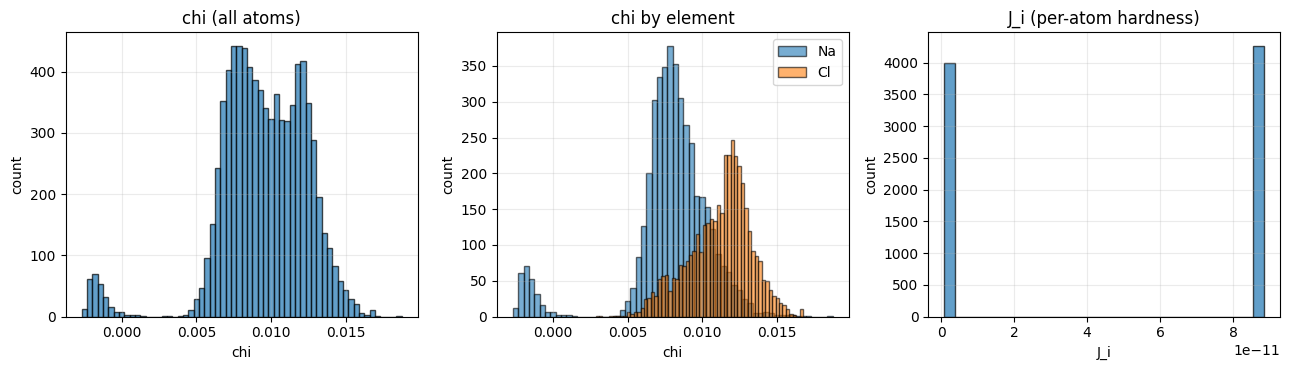

In [7]:
# 查看每原子 chi、电荷 q_eq 以及硬度 J 的分布
import matplotlib.pyplot as plt

mask_na = z_all == 11
mask_cl = z_all == 17

print("\n--- chi 分布 ---")
print("chi_all mean/std:", float(chi_all.mean()), float(chi_all.std()))
if mask_na.any():
    print("chi(Na) mean/std:", float(chi_all[mask_na].mean()), float(chi_all[mask_na].std()))
if mask_cl.any():
    print("chi(Cl) mean/std:", float(chi_all[mask_cl].mean()), float(chi_all[mask_cl].std()))

print("\n--- J（硬度）---")
# ChargeEq.elements 在本任务里应为 [11, 17]
print("ChargeEq.elements order expected: [11, 17]")
print("J_elem:", J_elem)
if J_i_all is not None:
    print("J_i_all mean/std:", float(J_i_all.mean()), float(J_i_all.std()))
    if mask_na.any():
        print("J_i(Na) unique:", np.unique(np.round(J_i_all[mask_na], 8)))
    if mask_cl.any():
        print("J_i(Cl) unique:", np.unique(np.round(J_i_all[mask_cl], 8)))
else:
    print("J_i_all is None（说明当前 forward 输出里没有 J_i；请确认已重启 kernel 并使用更新后的 cace/modules/charge_eq.py）")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

ax = axes[0]
ax.hist(chi_all, bins=60, alpha=0.7, edgecolor="black")
ax.set_title("chi (all atoms)")
ax.set_xlabel("chi")
ax.set_ylabel("count")
ax.grid(True, alpha=0.25)

ax = axes[1]
if mask_na.any():
    ax.hist(chi_all[mask_na], bins=60, alpha=0.6, label="Na", edgecolor="black")
if mask_cl.any():
    ax.hist(chi_all[mask_cl], bins=60, alpha=0.6, label="Cl", edgecolor="black")
ax.set_title("chi by element")
ax.set_xlabel("chi")
ax.set_ylabel("count")
ax.legend()
ax.grid(True, alpha=0.25)

ax = axes[2]
if J_i_all is not None:
    ax.hist(J_i_all, bins=30, alpha=0.7, edgecolor="black")
ax.set_title("J_i (per-atom hardness)")
ax.set_xlabel("J_i")
ax.set_ylabel("count")
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

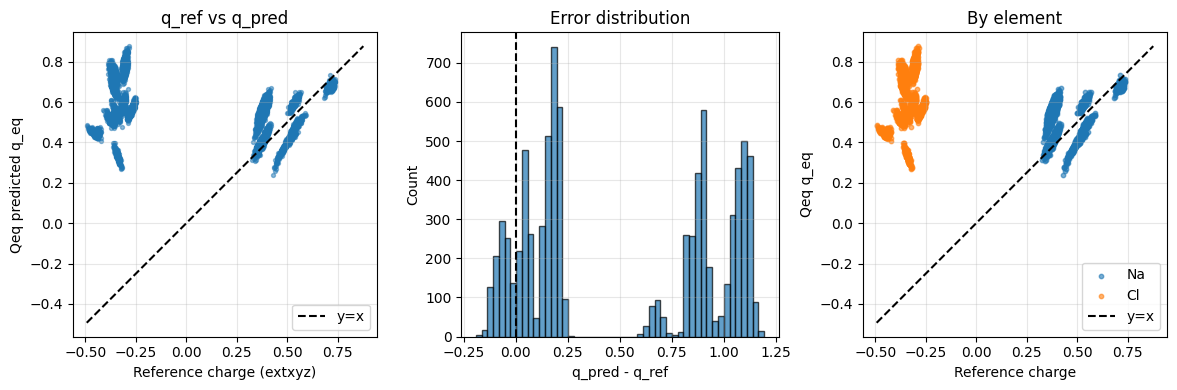

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# 1) 散点：q_ref vs q_pred
ax = axes[0]
ax.scatter(q_ref, q_pred, alpha=0.5, s=8)
mn, mx = min(q_ref.min(), q_pred.min()), max(q_ref.max(), q_pred.max())
ax.plot([mn, mx], [mn, mx], "k--", label="y=x")
ax.set_xlabel("Reference charge (extxyz)")
ax.set_ylabel("Qeq predicted q_eq")
ax.set_title("q_ref vs q_pred")
ax.legend()
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)

# 2) 误差分布直方图
ax = axes[1]
ax.hist(err, bins=50, edgecolor="black", alpha=0.7)
ax.axvline(0, color="k", linestyle="--")
ax.set_xlabel("q_pred - q_ref")
ax.set_ylabel("Count")
ax.set_title("Error distribution")
ax.grid(True, alpha=0.3)

# 3) 按元素分开的散点（Na / Cl）
ax = axes[2]
if mask_na.any():
    ax.scatter(q_ref[mask_na], q_pred[mask_na], alpha=0.6, s=10, label="Na", c="C0")
if mask_cl.any():
    ax.scatter(q_ref[mask_cl], q_pred[mask_cl], alpha=0.6, s=10, label="Cl", c="C1")
ax.plot([mn, mx], [mn, mx], "k--", label="y=x")
ax.set_xlabel("Reference charge")
ax.set_ylabel("Qeq q_eq")
ax.set_title("By element")
ax.legend()
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

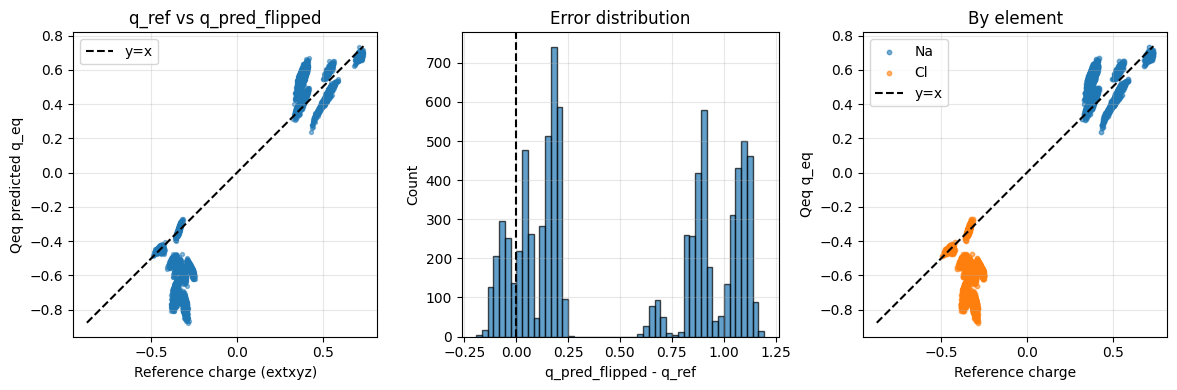

In [13]:

q_pred_flipped = q_pred.copy()
q_pred_flipped[mask_cl] *= -1.0

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# 1) 散点：q_ref vs q_pred_flipped
ax = axes[0]
ax.scatter(q_ref, q_pred_flipped, alpha=0.5, s=8)
mn, mx = min(q_ref.min(), q_pred_flipped.min()), max(q_ref.max(), q_pred_flipped.max())
ax.plot([mn, mx], [mn, mx], "k--", label="y=x")
ax.set_xlabel("Reference charge (extxyz)")
ax.set_ylabel("Qeq predicted q_eq")
ax.set_title("q_ref vs q_pred_flipped")
ax.legend()
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)

# 2) 误差分布直方图
ax = axes[1]
ax.hist(err, bins=50, edgecolor="black", alpha=0.7)
ax.axvline(0, color="k", linestyle="--")
ax.set_xlabel("q_pred_flipped - q_ref")
ax.set_ylabel("Count")
ax.set_title("Error distribution")
ax.grid(True, alpha=0.3)

# 3) 按元素分开的散点（Na / Cl）
ax = axes[2]
if mask_na.any():
    ax.scatter(q_ref[mask_na], q_pred_flipped[mask_na], alpha=0.6, s=10, label="Na", c="C0")
if mask_cl.any():
    ax.scatter(q_ref[mask_cl], q_pred_flipped[mask_cl], alpha=0.6, s=10, label="Cl", c="C1")
ax.plot([mn, mx], [mn, mx], "k--", label="y=x")
ax.set_xlabel("Reference charge")
ax.set_ylabel("Qeq q_eq")
ax.set_title("By element")
ax.legend()
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

